In [1]:
!nvidia-smi

Sat Dec 20 19:59:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.42                 Driver Version: 581.42         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 2000 Ada Gene...  WDDM  |   00000000:55:00.0  On |                  Off |
| 31%   56C    P8              5W /   70W |     292MiB /  16380MiB |     22%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"


In [3]:
# !hf auth login

In [4]:
from transformers import AutoProcessor, AutoModelForImageTextToText
from PIL import Image
import requests
import torch

model_id = "google/medgemma-4b-it"

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
processor = AutoProcessor.from_pretrained(model_id)

# Image attribution: Stillwaterising, CC0, via Wikimedia Commons
# image_url = "https://upload.wikimedia.org/wikipedia/commons/c/c8/Chest_Xray_PA_3-8-2010.png"
# image = Image.open(requests.get(image_url, headers={"User-Agent": "example"}, stream=True).raw)


image_path = "Dataset1/Covid19/COVID19(0).jpg"
image = Image.open(image_path)
messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": "You are an expert radiologist."}]
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Size of ribs?"},
            {"type": "image", "image": image}
        ]
    }
]

inputs = processor.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors="pt"
).to(model.device, dtype=torch.bfloat16)

input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**inputs, max_new_tokens=200, do_sample=False)
    generation = generation[0][input_len:]

decoded = processor.decode(generation, skip_special_tokens=True)
print(decoded)



`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Based on the provided chest X-ray, the ribs appear to be of normal size and shape. The rib cage is well-defined, and there are no obvious fractures or other abnormalities.

However, it's important to note that this is a limited assessment based on a single image. A complete evaluation would require a full series of chest radiographs, including AP and lateral views, and potentially additional imaging such as a CT scan, to rule out any subtle abnormalities.



In [5]:

from datasets import load_dataset

In [6]:
train_size = 400 # @param {type: "number"}
validation_size = 100  # @param {type: "number"}

data = load_dataset("Dataset1/", split="train")


Resolving data files:   0%|          | 0/2304 [00:00<?, ?it/s]

In [7]:
class_names = data.features["label"].names
print(class_names)


['Covid19', 'Normal', 'Pneumonia', 'Tuberculosis']


In [8]:
data = data.train_test_split(
    train_size=train_size,
    test_size=validation_size,
    shuffle=True,
    seed=42,
)

In [9]:
class_names = data["train"].features["label"].names
print(class_names)


['Covid19', 'Normal', 'Pneumonia', 'Tuberculosis']


In [10]:
from collections import Counter

labels = data["train"]["label"]
class_counts = Counter(labels)

class_names = data["train"].features["label"].names

for label_id, count in class_counts.items():
    print(f"{class_names[label_id]}: {count}")

Normal: 102
Tuberculosis: 104
Covid19: 96
Pneumonia: 98


In [11]:
data["validation"] = data.pop("test")

# Display dataset details
data

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 400
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 100
    })
})

In [12]:
from collections import Counter

labels = data["validation"]["label"]
class_counts = Counter(labels)

class_names = data["validation"].features["label"].names

for label_id, count in class_counts.items():
    print(f"{class_names[label_id]}: {count}")

Tuberculosis: 30
Normal: 32
Covid19: 20
Pneumonia: 18


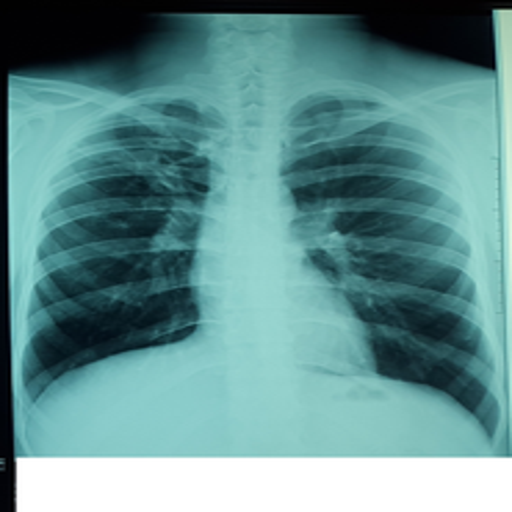

In [13]:
data["train"][1]["image"]


In [14]:
print(class_names[data["train"][1]["label"]])

Tuberculosis


In [15]:
from typing import Any

CLASSES = [
    "A: Covid19",
    "B: Normal",
    "C: Pneumonia",
    "D: Tuberculosis"
]

options = "\n".join(CLASSES)
PROMPT = f"What is the disease?\n{options}"


def format_data(example: dict[str, Any]) -> dict[str, Any]:
    example["messages"] = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                },
                {
                    "type": "text",
                    "text": PROMPT,
                },
            ],
        },
        {
            "role": "assistant",
            "content": [
                {
                    "type": "text",
                    "text": CLASSES[example["label"]],
                },
            ],
        },
    ]
    return example





In [16]:

data = data.map(format_data)

# Display a processed data sample
data["train"][1]
     

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 'label': 3,
 'messages': [{'content': [{'text': None, 'type': 'image'},
    {'text': 'What is the disease?\nA: Covid19\nB: Normal\nC: Pneumonia\nD: Tuberculosis',
     'type': 'text'}],
   'role': 'user'},
  {'content': [{'text': 'D: Tuberculosis', 'type': 'text'}],
   'role': 'assistant'}]}

In [17]:
data["validation"][99]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 'label': 1,
 'messages': [{'content': [{'text': None, 'type': 'image'},
    {'text': 'What is the disease?\nA: Covid19\nB: Normal\nC: Pneumonia\nD: Tuberculosis',
     'type': 'text'}],
   'role': 'user'},
  {'content': [{'text': 'B: Normal', 'type': 'text'}], 'role': 'assistant'}]}

In [18]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

model_id = "google/medgemma-4b-it"

# Check if GPU supports bfloat16
# if torch.cuda.get_device_capability()[0] < 8:
#     raise ValueError("GPU does not support bfloat16, please use a GPU that supports bfloat16.")

model_kwargs = dict(
    attn_implementation="eager",
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

model_kwargs["quantization_config"] = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=model_kwargs["torch_dtype"],
    bnb_4bit_quant_storage=model_kwargs["torch_dtype"],
)

model = AutoModelForImageTextToText.from_pretrained(model_id, **model_kwargs)
processor = AutoProcessor.from_pretrained(model_id)

# Use right padding to avoid issues during training
processor.tokenizer.padding_side = "right"

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [19]:
from peft import LoraConfig

peft_config = LoraConfig(
    lora_alpha=16,
    lora_dropout=0.05,
    r=16,
    bias="none",
    target_modules="all-linear",
    task_type="CAUSAL_LM",
    modules_to_save=[
        "lm_head",
        "embed_tokens",
    ],
)

In [20]:
from typing import Any


def collate_fn(examples: list[dict[str, Any]]):
    texts = []
    images = []
    for example in examples:
        images.append([example["image"].convert("RGB")])
        # images.append([example["image"]])
        texts.append(processor.apply_chat_template(
            example["messages"], add_generation_prompt=False, tokenize=False
        ).strip())

    # Tokenize the texts and process the images
    batch = processor(text=texts, images=images, return_tensors="pt", padding=True)

    # The labels are the input_ids, with the padding and image tokens masked in
    # the loss computation
    labels = batch["input_ids"].clone()

    # Mask image tokens
    image_token_id = [
        processor.tokenizer.convert_tokens_to_ids(
            processor.tokenizer.special_tokens_map["boi_token"]
        )
    ]
    # Mask tokens that are not used in the loss computation
    labels[labels == processor.tokenizer.pad_token_id] = -100
    labels[labels == image_token_id] = -100
    labels[labels == 262144] = -100

    batch["labels"] = labels
    return batch

In [21]:
from trl import SFTConfig

num_train_epochs = 5  # @param {type: "number"}
learning_rate = 1e-4  # @param {type: "number"}

args = SFTConfig(
    output_dir="medgemma-4b-it-sft-lora-crc100k",            # Directory and Hub repository id to save the model to
    num_train_epochs=num_train_epochs,                       # Number of training epochs
    per_device_train_batch_size=2,                           # Batch size per device during training
    per_device_eval_batch_size=2,                            # Batch size per device during evaluation
    gradient_accumulation_steps=2,                           # Number of steps before performing a backward/update pass
    gradient_checkpointing=True,                             # Enable gradient checkpointing to reduce memory usage
    optim="adamw_torch_fused",                               # Use fused AdamW optimizer for better performance
    logging_steps=1,                                        # Number of steps between logs
    save_strategy="epoch",                                   # Save checkpoint every epoch
    eval_strategy="steps",                                   # Evaluate every `eval_steps`
    eval_steps=1,                                           # Number of steps between evaluations
    learning_rate=learning_rate,                             # Learning rate based on QLoRA paper
    bf16=True,                                               # Use bfloat16 precision
    max_grad_norm=0.3,                                       # Max gradient norm based on QLoRA paper
    warmup_ratio=0.03,                                       # Warmup ratio based on QLoRA paper
    lr_scheduler_type="linear",                              # Use linear learning rate scheduler
    push_to_hub=True,                                        # Push model to Hub
    report_to="tensorboard",                                 # Report metrics to tensorboard
    gradient_checkpointing_kwargs={"use_reentrant": False},  # Set gradient checkpointing to non-reentrant to avoid issues
    dataset_kwargs={"skip_prepare_dataset": True},           # Skip default dataset preparation to preprocess manually
    remove_unused_columns = False,                           # Columns are unused for training but needed for data collator
    label_names=["labels"],
)

In [22]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=data["train"],
    eval_dataset=data["validation"].shuffle().select(range(30)),  # Use subset of validation set for faster run
    peft_config=peft_config,
    processing_class=processor,
    data_collator=collate_fn,
)

C:\Users\Dell\anaconda3\Lib\site-packages\peft\tuners\tuners_utils.py:1222: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


In [23]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,6.784400,6.824378,1.639255,1190.000000,0.441929
2,7.057800,6.815576,1.642380,2379.000000,0.441126
3,6.813200,6.778252,1.641677,3568.000000,0.443585
4,6.810800,6.683883,1.652669,4759.000000,0.446888
5,6.661500,6.512633,1.664614,5951.000000,0.451837
6,6.533500,6.179734,1.691620,7139.000000,0.476551
7,5.890200,5.765406,1.714869,8334.000000,0.495442
8,5.725500,5.244130,1.770275,9524.000000,0.520919
9,5.137000,4.880906,1.817094,10717.000000,0.547991
10,4.979400,4.561767,1.894406,11907.000000,0.557827


TrainOutput(global_step=500, training_loss=0.24629942421615122, metrics={'train_runtime': 431962.6654, 'train_samples_per_second': 0.005, 'train_steps_per_second': 0.001, 'total_flos': 1.5506823695371008e+16, 'train_loss': 0.24629942421615122, 'epoch': 5.0})

In [24]:
trainer.save_model()

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


In [25]:
del model
del trainer
torch.cuda.empty_cache()

In [26]:
# from transformers import AutoProcessor, AutoModelForImageTextToText
# from PIL import Image
# import requests
# import torch

# # model_id = "poornanandnaik24/medgemma-4b-it-sft-lora-crc100k"

# model = AutoModelForImageTextToText.from_pretrained(
#     model_id,
#     torch_dtype=torch.bfloat16,
#     device_map="auto"
# )
# processor = AutoProcessor.from_pretrained(model_id)

In [27]:
from typing import Any

from datasets import load_dataset


def format_test_data(example: dict[str, Any]) -> dict[str, Any]:
    example["messages"] = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                },
                {
                    "type": "text",
                    "text": PROMPT,
                },
            ],
        },
    ]
    return example


test_data = load_dataset("TestDataset2/", split="train")

test_data = test_data.shuffle(seed=42).select(range(100))
test_data = test_data.map(format_test_data)
     

Resolving data files:   0%|          | 0/649 [00:00<?, ?it/s]

In [28]:
len(test_data)

100

In [29]:
print(test_data["image"])

Column([<PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512 at 0x1E9F1C6F750>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512 at 0x1E8E4A9F610>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1424x1224 at 0x1E8E4A9E5D0>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1164x801 at 0x1E8E4A9DD10>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512 at 0x1E8E4A9D590>])


In [30]:
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

# Ground-truth labels
REFERENCES = test_data["label"]


def compute_metrics(predictions: list[int]) -> dict[str, float]:
    metrics = {}
    metrics.update(accuracy_metric.compute(
        predictions=predictions,
        references=REFERENCES,
    ))
    metrics.update(f1_metric.compute(
        predictions=predictions,
        references=REFERENCES,
        average="weighted",
    ))
    return metrics
     

In [31]:
from datasets import ClassLabel


test_data = test_data.cast_column(
    "label",
    ClassLabel(names=CLASSES)
)

LABEL_FEATURE = test_data.features["label"]
# Mapping to alternative label format, `(X) tissue type`
ALT_LABELS = dict([
    (label, f"({label.replace(': ', ') ')}") for label in CLASSES
])


def postprocess(prediction: list[dict[str, str]], do_full_match: bool=False) -> int:
    response_text = prediction[0]["generated_text"]
    if do_full_match:
        return LABEL_FEATURE.str2int(response_text)
    for label in CLASSES:
        if label in response_text or ALT_LABELS[label] in response_text:
            return LABEL_FEATURE.str2int(label)
    return -1
     

In [32]:
print(len(test_data))

100


In [33]:


from transformers import pipeline

pt_pipe = pipeline(
    "image-text-to-text",
    model=model_id,
    torch_dtype=torch.bfloat16,
)

# Set `do_sample = False` for deterministic responses
pt_pipe.model.generation_config.do_sample = False
pt_pipe.model.generation_config.pad_token_id = processor.tokenizer.eos_token_id
     

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0


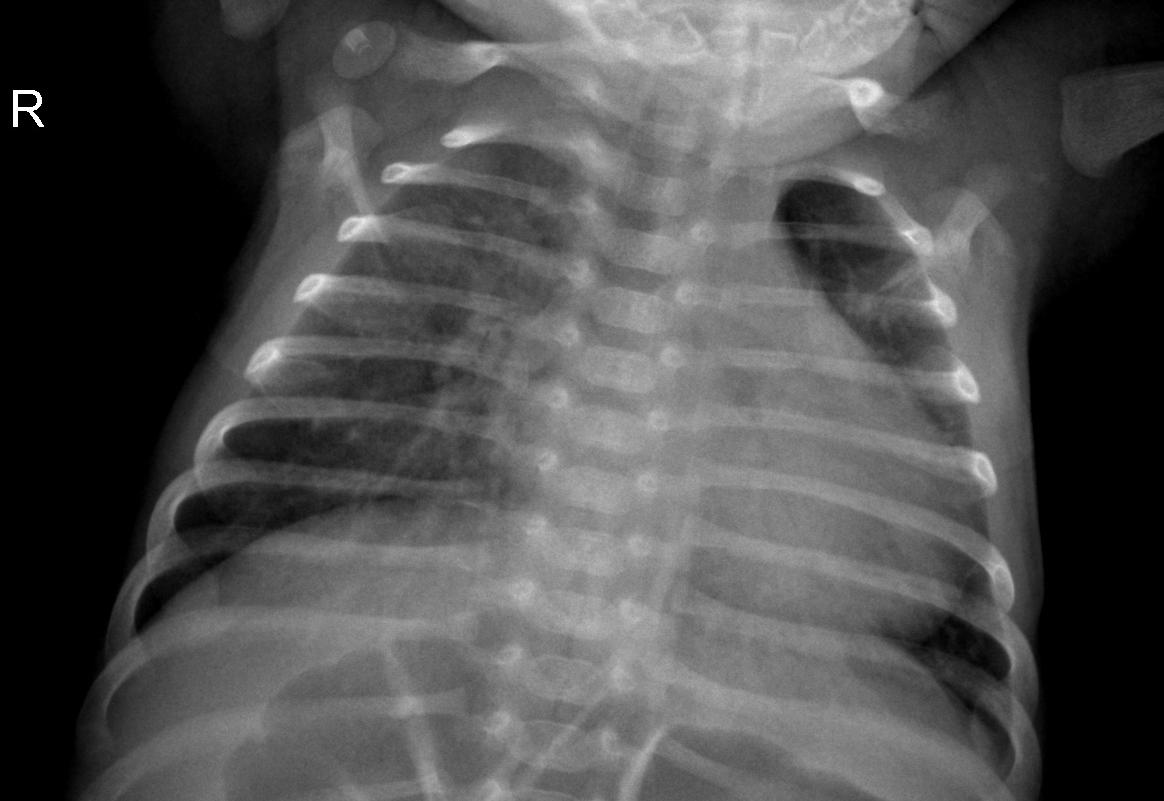

In [34]:
test_data["image"][3]

In [35]:
test_data["image"]

Column([<PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512 at 0x1E8EC404910>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512 at 0x1E8EC4047D0>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1424x1224 at 0x1E8EC404550>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1164x801 at 0x1E8EC404CD0>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512 at 0x1E8EC404B90>])

In [36]:


import torch
from tqdm import tqdm

images = [img for img in test_data["image"]]

formatted_texts = []
for msg in test_data["messages"]:
    text_str = pt_pipe.tokenizer.apply_chat_template(
        msg, 
        tokenize=False, 
        add_generation_prompt=True
    )
    if "<image>" not in text_str:
        text_str = "<image>" + text_str
    formatted_texts.append(text_str)

def data_generator():
    for img, txt in zip(images, formatted_texts):
        yield {"images": img, "text": txt}


pt_outputs = []
for out in tqdm(pt_pipe(data_generator(), batch_size=1, max_new_tokens=40), total=len(images)):
    pt_outputs.append(out)




100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [44:12<00:00, 26.53s/it]


In [37]:
pt_outputs

[[{'input_text': '<image><bos><start_of_turn>user\n<start_of_image>What is the disease?\nA: Covid19\nB: Normal\nC: Pneumonia\nD: Tuberculosis<end_of_turn>\n<start_of_turn>model\n',
   'generated_text': "<image><bos><start_of_turn>user\n<start_of_image>What is the disease?\nA: Covid19\nB: Normal\nC: Pneumonia\nD: Tuberculosis<end_of_turn>\n<start_of_turn>model\nBased on the chest X-ray image, the most likely answer is **B: Normal**.\n\nHere's why:\n\n*   **Normal Chest X-ray:** The image shows the typical"}],
 [{'input_text': '<image><bos><start_of_turn>user\n<start_of_image>What is the disease?\nA: Covid19\nB: Normal\nC: Pneumonia\nD: Tuberculosis<end_of_turn>\n<start_of_turn>model\n',
   'generated_text': "<image><bos><start_of_turn>user\n<start_of_image>What is the disease?\nA: Covid19\nB: Normal\nC: Pneumonia\nD: Tuberculosis<end_of_turn>\n<start_of_turn>model\nBased on the chest X-ray image, the most likely answer is **B: Normal**.\n\nHere's why:\n\n*   **Normal Chest X-ray:** The 

In [38]:
import pandas as pd
import re

# Mapping for Ground Truth and Prediction
label_map = {0: 'Covid19', 1: 'Normal', 2: 'Pneumonia', 3: 'Tuberculosis'}
letter_to_label = {'A': 'Covid19', 'B': 'Normal', 'C': 'Pneumonia', 'D': 'Tuberculosis'}

final_preds = []

for out in pt_outputs:
    # Get the generated text
    text = out[0]['generated_text']
    
    # Logic to find the assistant's specific answer
    # It looks for **B: Normal** or just the bolded letter **A**
    bold_match = re.search(r'\*\*([A-D])[:\s]', text) # Finds **A:**, **B:**, etc.
    
    if bold_match:
        letter = bold_match.group(1)
        final_preds.append(letter_to_label[letter])
    else:
        # Fallback: Search for the disease name directly if bolding is missing
        found = "Unknown"
        for name in label_map.values():
            if name.lower() in text.lower():
                found = name
                break
        final_preds.append(found)

# 2. Update the DataFrame
results_df = pd.DataFrame({
    "Ground_Truth_Label": [label_map[i] for i in test_data["label"]],
    "Model_Prediction_Label": final_preds
})

print("--- Cleaned Comparison ---")
print(results_df.head(20))

--- Cleaned Comparison ---
   Ground_Truth_Label Model_Prediction_Label
0        Tuberculosis                 Normal
1              Normal                 Normal
2           Pneumonia                 Normal
3           Pneumonia                 Normal
4              Normal                 Normal
5           Pneumonia                 Normal
6              Normal                 Normal
7             Covid19                 Normal
8             Covid19              Pneumonia
9        Tuberculosis                 Normal
10          Pneumonia                 Normal
11            Covid19                 Normal
12          Pneumonia                 Normal
13            Covid19                 Normal
14             Normal                 Normal
15          Pneumonia                 Normal
16            Covid19                 Normal
17             Normal                 Normal
18          Pneumonia                 Normal
19             Normal                 Normal


In [39]:
# pt_predictions = [postprocess(out) for out in pt_outputs]
    

In [40]:
# pt_predictions

In [41]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Ensure we are comparing the mapped labels
y_true = results_df["Ground_Truth_Label"]
y_pred = results_df["Model_Prediction_Label"]

# Calculate Metrics
acc = accuracy_score(y_true, y_pred)
# 'weighted' f1 accounts for the number of samples in each class
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Overall Accuracy: {acc:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")

# Detailed breakdown for each disease
print("\n--- Detailed Performance Report ---")
print(classification_report(y_true, y_pred))

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Overall Accuracy: 0.3800
Weighted F1 Score: 0.2973

--- Detailed Performance Report ---
              precision    recall  f1-score   support

     Covid19       0.53      0.24      0.33        33
      Normal       0.38      1.00      0.55        27
   Pneumonia       0.23      0.12      0.15        26
Tuberculosis       0.00      0.00      0.00        14

    accuracy                           0.38       100
   macro avg       0.28      0.34      0.26       100
weighted avg       0.34      0.38      0.30       100



C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [42]:
ft_pipe = pipeline(
    "image-text-to-text",
    model=args.output_dir,
    processor=processor,
    torch_dtype=torch.bfloat16,
)

# Set `do_sample = False` for deterministic responses
ft_pipe.model.generation_config.do_sample = False
ft_pipe.model.generation_config.pad_token_id = processor.tokenizer.eos_token_id
# Use left padding during inference
processor.tokenizer.padding_side = "left"

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

C:\Users\Dell\anaconda3\Lib\site-packages\peft\tuners\tuners_utils.py:1222: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)
Device set to use cuda:0


In [43]:
import torch
from tqdm import tqdm

images = [img for img in test_data["image"]]

formatted_texts = []
for msg in test_data["messages"]:
    text_str = ft_pipe.tokenizer.apply_chat_template(
        msg, 
        tokenize=False, 
        add_generation_prompt=True
    )
    if "<image>" not in text_str:
        text_str = "<image>" + text_str
    formatted_texts.append(text_str)

def data_generator():
    for img, txt in zip(images, formatted_texts):
        yield {"images": img, "text": txt}


ft_outputs = []
for out in tqdm(ft_pipe(data_generator(), batch_size=1, max_new_tokens=40), total=len(images)):
    ft_outputs.append(out)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [03:18<00:00,  1.99s/it]


In [44]:
ft_outputs

[[{'input_text': '<image><bos><start_of_turn>user\n<start_of_image>What is the disease?\nA: Covid19\nB: Normal\nC: Pneumonia\nD: Tuberculosis<end_of_turn>\n<start_of_turn>model\n',
   'generated_text': '<image><bos><start_of_turn>user\n<start_of_image>What is the disease?\nA: Covid19\nB: Normal\nC: Pneumonia\nD: Tuberculosis<end_of_turn>\n<start_of_turn>model\nD: Tuberculosis'}],
 [{'input_text': '<image><bos><start_of_turn>user\n<start_of_image>What is the disease?\nA: Covid19\nB: Normal\nC: Pneumonia\nD: Tuberculosis<end_of_turn>\n<start_of_turn>model\n',
   'generated_text': '<image><bos><start_of_turn>user\n<start_of_image>What is the disease?\nA: Covid19\nB: Normal\nC: Pneumonia\nD: Tuberculosis<end_of_turn>\n<start_of_turn>model\nB: Normal'}],
 [{'input_text': '<image><bos><start_of_turn>user\n<start_of_image>What is the disease?\nA: Covid19\nB: Normal\nC: Pneumonia\nD: Tuberculosis<end_of_turn>\n<start_of_turn>model\n',
   'generated_text': '<image><bos><start_of_turn>user\n<sta

In [45]:
import pandas as pd
import re

label_map = {0: 'Covid19', 1: 'Normal', 2: 'Pneumonia', 3: 'Tuberculosis'}
letter_to_label = {'A': 'Covid19', 'B': 'Normal', 'C': 'Pneumonia', 'D': 'Tuberculosis'}

final_preds = []


for out in ft_outputs:
    full_text = out[0]['generated_text']
    
    if "model\n" in full_text:
        response = full_text.split("model\n")[-1].strip()
    else:
        response = full_text.strip()

    letter_match = re.search(r'([A-D])(?::|\s|$)', response)
    
    if letter_match:
        letter = letter_match.group(1)
        final_preds.append(letter_to_label[letter])
    else:
        found = "Unknown"
        for name in label_map.values():
            if name.lower() in response.lower():
                found = name
                break
        final_preds.append(found)

# 2. Create the DataFrame
results_df = pd.DataFrame({
    "Ground_Truth_Label": [label_map[i] for i in test_data["label"]],
    "Model_Prediction_Label": final_preds
})

print("--- Cleaned Comparison ---")
print(results_df.head(20))

--- Cleaned Comparison ---
   Ground_Truth_Label Model_Prediction_Label
0        Tuberculosis           Tuberculosis
1              Normal                 Normal
2           Pneumonia              Pneumonia
3           Pneumonia              Pneumonia
4              Normal                 Normal
5           Pneumonia              Pneumonia
6              Normal                 Normal
7             Covid19                Covid19
8             Covid19                Covid19
9        Tuberculosis           Tuberculosis
10          Pneumonia              Pneumonia
11            Covid19                Covid19
12          Pneumonia              Pneumonia
13            Covid19                 Normal
14             Normal                 Normal
15          Pneumonia              Pneumonia
16            Covid19                Covid19
17             Normal                 Normal
18          Pneumonia              Pneumonia
19             Normal                 Normal


In [46]:
from sklearn.metrics import accuracy_score, f1_score, classification_report


y_true = results_df["Ground_Truth_Label"]
y_pred = results_df["Model_Prediction_Label"]


acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Overall Accuracy: {acc:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")

print("\n--- Detailed Performance Report ---")
print(classification_report(y_true, y_pred))

Overall Accuracy: 0.9000
Weighted F1 Score: 0.8995

--- Detailed Performance Report ---
              precision    recall  f1-score   support

     Covid19       0.96      0.79      0.87        33
      Normal       0.79      1.00      0.89        27
   Pneumonia       0.93      0.96      0.94        26
Tuberculosis       1.00      0.86      0.92        14

    accuracy                           0.90       100
   macro avg       0.92      0.90      0.90       100
weighted avg       0.91      0.90      0.90       100

